Jason Stys

In [ ]:
import pandas as pd

# Same rows as table
results_df = pd.DataFrame([
    {"#Hidden layer": 2, "Activation Function": "ReLU",    "Learning Rate": 0.1,  "Accuracy": "XX.XX"},
    {"#Hidden layer": 2, "Activation Function": "ReLU",    "Learning Rate": 0.01, "Accuracy": "XX.XX"},
    {"#Hidden layer": 2, "Activation Function": "ReLU",    "Learning Rate": 0.5,  "Accuracy": "XX.XX"},
    {"#Hidden layer": 2, "Activation Function": "Sigmoid", "Learning Rate": 0.1,  "Accuracy": "XX.XX"},
    {"#Hidden layer": 2, "Activation Function": "Sigmoid", "Learning Rate": 0.01, "Accuracy": "XX.XX"},
    {"#Hidden layer": 2, "Activation Function": "Sigmoid", "Learning Rate": 0.5,  "Accuracy": "XX.XX"},
    {"#Hidden layer": 3, "Activation Function": "Sigmoid", "Learning Rate": 0.1,  "Accuracy": "XX.XX"},
    {"#Hidden layer": 3, "Activation Function": "ReLU",    "Learning Rate": 0.1,  "Accuracy": "XX.XX"},
])

results_df


,#Hidden layer,Activation Function,Learning Rate,Accuracy
0,2,ReLU,0.10,XX.XX
1,2,ReLU,0.01,XX.XX
2,2,ReLU,0.50,XX.XX
3,2,Sigmoid,0.10,XX.XX
4,2,Sigmoid,0.01,XX.XX
5,2,Sigmoid,0.50,XX.XX
6,3,Sigmoid,0.10,XX.XX
7,3,ReLU,0.10,XX.XX


In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization, Activation
from tensorflow.keras.optimizers import SGD

from matplotlib import pyplot as plt
import pandas as pd

# make results more repeatable
tf.random.set_seed(42)


In [ ]:
(x_train_raw, y_train_raw), (x_valid_raw, y_valid_raw) = mnist.load_data()

x_train_raw.shape, x_valid_raw.shape


((60000, 28, 28), (10000, 28, 28))

In [ ]:
# Flatten images: (N, 28, 28) -> (N, 784), and scale uint8 [0..255] -> float32 [0..1]
X_train = x_train_raw.reshape(60000, 784).astype("float32")
X_valid = x_valid_raw.reshape(10000, 784).astype("float32")

X_train /= 255.0
X_valid /= 255.0

# One hot encode labels
n_classes = 10
y_train = keras.utils.to_categorical(y_train_raw, n_classes)
y_valid = keras.utils.to_categorical(y_valid_raw, n_classes)

X_train.shape, y_train.shape, X_valid.shape, y_valid.shape


((60000, 784), (60000, 10), (10000, 784), (10000, 10))

In [ ]:
def build_mlp(n_hidden_layers=2, activation="relu", learning_rate=0.1,
              hidden_units=64, use_batchnorm=False, dropout_rate=0.0):
    model = Sequential()
    model.add(keras.layers.Input(shape=(784,)))

    for _ in range(n_hidden_layers):
        # Dense first (no activation), then BN, then activation layer
        model.add(Dense(hidden_units, activation=None))
        if use_batchnorm:
            model.add(BatchNormalization())
        model.add(Activation(activation))
        if dropout_rate and dropout_rate > 0:
            model.add(Dropout(dropout_rate))

    model.add(Dense(10, activation="softmax"))

    opt = SGD(learning_rate=learning_rate)  # (lr=...) is deprecated in modern Keras
    model.compile(loss="categorical_crossentropy", optimizer=opt, metrics=["accuracy"])
    return model


In [ ]:
n_hidden_layers = 2
activation = "relu"
learning_rate = 0.1

model = build_mlp(
    n_hidden_layers=n_hidden_layers,
    activation=activation,
    learning_rate=learning_rate,
    hidden_units=64,
    use_batchnorm=False,
    dropout_rate=0.0
)

model.summary()

history = model.fit(
    X_train, y_train,
    batch_size=128,
    epochs=20,
    verbose=1,
    validation_data=(X_valid, y_valid)
)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │        50,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 55,050 (215.04 KB)

 Trainable params: 55,050 (215.04 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.7650 - loss: 0.8434 - val_accuracy: 0.9174 - val_loss: 0.2839
Epoch 2/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9271 - loss: 0.2525 - val_accuracy: 0.9373 - val_loss: 0.2050
Epoch 3/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9454 - loss: 0.1872 - val_accuracy: 0.9482 - val_loss: 0.1664
Epoch 4/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9554 - loss: 0.1518 - val_accuracy: 0.9553 - val_loss: 0.1450
Epoch 5/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9628 - loss: 0.1285 - val_accuracy: 0.9584 - val_loss: 0.1311
Epoch 6/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9681 - loss: 0.1116 - val_accuracy: 0.9620 - val_loss: 0.1212
Epoch 7/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9717 - loss: 0.0986 - val_accuracy: 0.9646 - val_loss: 0.1140
Epoch 8/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9752 - loss: 0.0881 - val_accuracy: 0.

In [ ]:
val_loss, val_acc = model.evaluate(X_valid, y_valid, verbose=0)
print(f"Validation accuracy: {val_acc*100:.2f}%")


Validation accuracy: 97.32%


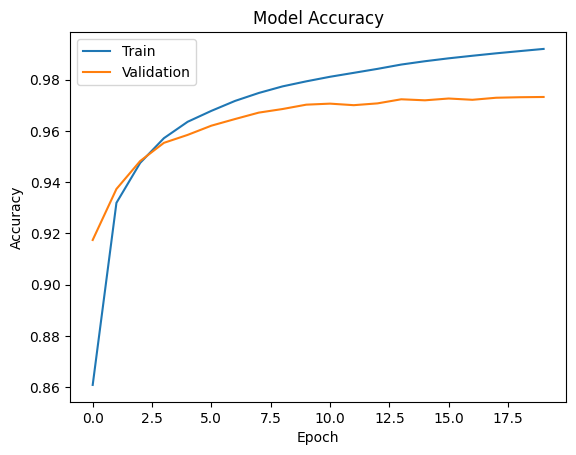

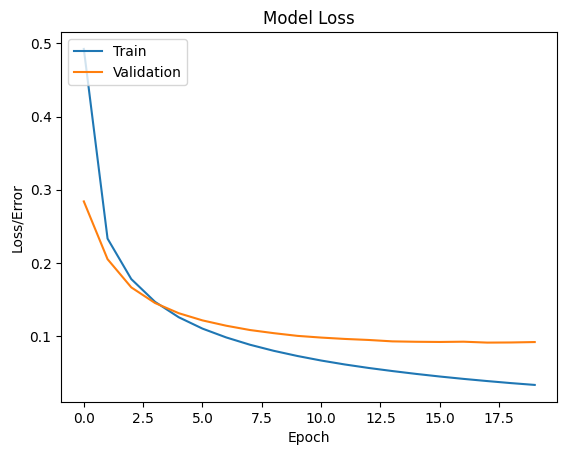

In [ ]:
# Accuracy plot
plt.plot(history.history["accuracy"])
plt.plot(history.history["val_accuracy"])
plt.title("Model Accuracy")
plt.ylabel("Accuracy")
plt.xlabel("Epoch")
plt.legend(["Train", "Validation"], loc="upper left")
plt.show()

# Loss plot
plt.plot(history.history["loss"])
plt.plot(history.history["val_loss"])
plt.title("Model Loss")
plt.ylabel("Loss/Error")
plt.xlabel("Epoch")
plt.legend(["Train", "Validation"], loc="upper left")
plt.show()


In [ ]:
import time
import tensorflow as tf

# tf.data speeds things up vs feeding numpy each time
train_ds = tf.data.Dataset.from_tensor_slices((X_train, y_train)) \
    .shuffle(10000).batch(256).prefetch(tf.data.AUTOTUNE)

valid_ds = tf.data.Dataset.from_tensor_slices((X_valid, y_valid)) \
    .batch(256).prefetch(tf.data.AUTOTUNE)

def run_experiment(n_hidden_layers, activation, learning_rate, epochs=20):
    model = build_mlp(
        n_hidden_layers=n_hidden_layers,
        activation=activation,
        learning_rate=learning_rate,
        hidden_units=64,
        use_batchnorm=False,
        dropout_rate=0.0
    )
    history = model.fit(
        train_ds,
        epochs=epochs,
        verbose=0,
        validation_data=valid_ds
    )
    _, val_acc = model.evaluate(valid_ds, verbose=0)
    return val_acc

configs = [
    (2, "relu",    0.1),
    (2, "relu",    0.01),
    (2, "relu",    0.5),
    (2, "sigmoid", 0.1),
    (2, "sigmoid", 0.01),
    (2, "sigmoid", 0.5),
    (3, "sigmoid", 0.1),
    (3, "relu",    0.1),
]

filled = results_df.copy()

t0 = time.perf_counter()
for i, (h, act, lr) in enumerate(configs, start=1):
    start = time.perf_counter()
    print(f"Running {i}/{len(configs)}: layers={h}, act={act}, lr={lr} ...")
    acc = run_experiment(h, act, lr, epochs=20)
    filled.loc[i-1, "Accuracy"] = f"{acc*100:.2f}"
    print(f"  done in {time.perf_counter()-start:.1f}s -> {acc*100:.2f}%\n")

print(f"Total time: {time.perf_counter()-t0:.1f}s")
filled


Running 1/8: layers=2, act=relu, lr=0.1 ...
  done in 24.9s -> 97.05%

Running 2/8: layers=2, act=relu, lr=0.01 ...
  done in 24.2s -> 92.96%

Running 3/8: layers=2, act=relu, lr=0.5 ...
  done in 25.0s -> 97.70%

Running 4/8: layers=2, act=sigmoid, lr=0.1 ...
  done in 25.3s -> 92.77%

Running 5/8: layers=2, act=sigmoid, lr=0.01 ...
  done in 23.8s -> 68.95%

Running 6/8: layers=2, act=sigmoid, lr=0.5 ...
  done in 23.5s -> 96.81%

Running 7/8: layers=3, act=sigmoid, lr=0.1 ...
  done in 24.9s -> 90.97%

Running 8/8: layers=3, act=relu, lr=0.1 ...
  done in 23.9s -> 97.42%

Total time: 195.5s


,#Hidden layer,Activation Function,Learning Rate,Accuracy
0,2,ReLU,0.10,97.05
1,2,ReLU,0.01,92.96
2,2,ReLU,0.50,97.70
3,2,Sigmoid,0.10,92.77
4,2,Sigmoid,0.01,68.95
5,2,Sigmoid,0.50,96.81
6,3,Sigmoid,0.10,90.97
7,3,ReLU,0.10,97.42
